# Before you start :
   - These exercises are related to the Subsetting and Descriptive Stats lessons.
   - Keep in mind that you need to use some of the functions you learned in the previous lessons.
   - All datasets are provided in the `your-code` folder of this lab.
   - Elaborate your codes and outputs as much as you can.
   - Try your best to answer the questions and complete the tasks and most importantly enjoy the process!!!

#### Import all the libraries that are necessary

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

# Challenge 1

#### In this challenge we will use the `Temp_States.csv` file. 

#### First import it into a data frame called `temp`.

In [164]:
temp = pd.read_csv("Temp_States.csv")

#### Print `temp`

In [165]:
print(temp)

         City        State  Temperature
0         NYC     New York    19.444444
1      Albany     New York     9.444444
2     Buffalo     New York     3.333333
3    Hartford  Connecticut    17.222222
4  Bridgeport  Connecticut    14.444444
5      Treton   New Jersey    22.222222
6      Newark   New Jersey    20.000000


#### Explore the data types of the Temp dataframe. What type of data do we have? Comment your result.

In [166]:
temp.info() # For the column 'City' the data type is object (string). For the column'State' the data type is object (string). finally for the column 'Temperature' the data type is float64. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         7 non-null      object 
 1   State        7 non-null      object 
 2   Temperature  7 non-null      float64
dtypes: float64(1), object(2)
memory usage: 300.0+ bytes


#### Select the rows where state is New York

In [167]:
st_ny = temp[temp['State'] == 'New York']
print(st_ny)

      City     State  Temperature
0      NYC  New York    19.444444
1   Albany  New York     9.444444
2  Buffalo  New York     3.333333


#### What is the average of the temperature of cities in New York?

In [169]:
print(f" The average of the temperature of cities in New York: {round(st_ny['Temperature'].mean(), 2)}")

 The average of the temperature of cities in New York: 10.74


#### We want to know cities and states with Temperature above 15 degress Celcius

In [170]:
ab_15 = temp[temp["Temperature"] > 15]

print("Cities and States with temperature above 15 degress Celcius:")
for i in range(0,len(ab_15["City"])):
    print(f"{ab_15['City'].iloc[i]}, {ab_15['State'].iloc[i]}")

Cities and States with temperature above 15 degress Celcius:
NYC, New York
Hartford, Connecticut
Treton, New Jersey
Newark, New Jersey


#### Now, return only the cities that have a temperature above 15 degress Celcius

In [171]:
print(f"Cities with temperature above 15 degress Celcius:")
for i in range(0,len(ab_15["City"])):
    print(f"{ab_15['City'].iloc[i]}")

Cities with temperature above 15 degress Celcius:
NYC
Hartford
Treton
Newark


#### We want to know which cities have a temperature above 15 degrees Celcius and below 20 degrees Celcius

*Hint: First write the condition then select the rows.*

In [172]:
btw_15_20 = temp[(temp["Temperature"] > 15) & (temp["Temperature"] < 20)]
print(f"Cities with temperature above 15 and below 20 degrees Celcius:")
for i in range(len(btw_15_20["City"])):
    print(f"{btw_15_20['City'].iloc[i]}")

Cities with temperature above 15 and below 20 degrees Celcius:
NYC
Hartford


#### Find the mean and the standard deviation of the temperature of each state.

*Hint: Use functions from Data Manipulation lesson*

In [173]:
print("The mean of the temperature of each state are:")
st_temp = temp.groupby(["State"])["Temperature"].mean().round(2)
print(st_temp)

The mean of the temperature of each state are:
State
Connecticut    15.83
New Jersey     21.11
New York       10.74
Name: Temperature, dtype: float64


In [174]:
print("The standard deviation of the temperature of each state are:")
st_temp = temp.groupby(["State"])["Temperature"].std().round(2)
print(st_temp)

The standard deviation of the temperature of each state are:
State
Connecticut    1.96
New Jersey     1.57
New York       8.13
Name: Temperature, dtype: float64


# Challenge 2

#### Load the `employee.csv` file into a DataFrame. Call the dataframe `employee`

In [175]:
employee = pd.read_csv("Employee.csv")

#### Explore the data types of the Temp dataframe. Comment your results

In [176]:
employee.info() 

#The columns "Name", "Department", "Education", "Gender" and "Title" have an object type data (strings). 
#The columns "Years" and "Salary" have a data type int64.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        9 non-null      object
 1   Department  9 non-null      object
 2   Education   9 non-null      object
 3   Gender      9 non-null      object
 4   Title       9 non-null      object
 5   Years       9 non-null      int64 
 6   Salary      9 non-null      int64 
dtypes: int64(2), object(5)
memory usage: 636.0+ bytes


#### Show visually the frequency distribution (histogram) of the employee dataset. In few words describe these histograms?

In [177]:
#The first instagram with the 'years' title describe the frecuenqcy of the amount of employees that have worked in the company for 1, 2, 3, 4, 7 and 8 years. 
#The seconf histagram shows the number of employees and the Salary they have 30, 35, etc. 

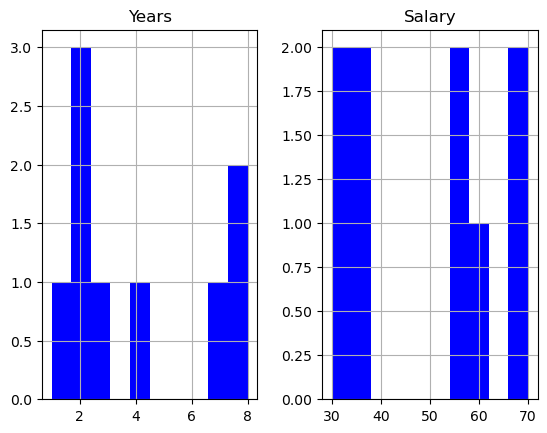

In [178]:
employee.hist(bins=10, color="blue")
plt.show()

#### What's the average salary in this company?

In [179]:
print(f"The average salary in this company is: {employee["Salary"]. mean().round(2)}")

The average salary in this company is: 48.89


#### What's the highest salary?

In [180]:
print(f"The highest salary is: {employee["Salary"].max()}")

The highest salary is: 70


#### What's the lowest salary?

In [181]:
print(f"The lowest salary is: {employee["Salary"].min()}")

The lowest salary is: 30


#### Who are the employees with the lowest salary?

In [182]:
min_sal = employee["Salary"].min()
print("The employees with the lowest salary are:")

min_sal_emp = employee[employee["Salary"] == min_sal]

for name in min_sal_emp["Name"]:
    print(name)

The employees with the lowest salary are:
Maria
David


#### Could you give all the information about an employee called David?

In [183]:
print(employee[employee["Name"] == "David"])

    Name Department Education Gender    Title  Years  Salary
2  David         HR    Master      M  analyst      2      30


#### Could you give only David's salary?

In [184]:
salary_d = employee[(employee["Name"] == "David")]["Salary"]
for sal in salary_d:
    print(f"David salary is: {sal}")

David salary is: 30


#### Print all the rows where job title is associate

In [185]:
ass_empl = employee[employee["Title"] == "associate"]
print(ass_empl)

     Name Department Education Gender      Title  Years  Salary
4  Samuel      Sales    Master      M  associate      3      55
5     Eva      Sales  Bachelor      F  associate      2      55
7   Pedro         IT       Phd      M  associate      7      60


#### Print the first 3 rows of your dataframe

##### Tip : There are 2 ways to do it. Do it both ways

In [186]:
employee.head(3)

,Name,Department,Education,Gender,Title,Years,Salary
0,Jose,IT,Bachelor,M,analyst,1,35
1,Maria,IT,Master,F,analyst,2,30
2,David,HR,Master,M,analyst,2,30


In [187]:
print(employee[:3])

    Name Department Education Gender    Title  Years  Salary
0   Jose         IT  Bachelor      M  analyst      1      35
1  Maria         IT    Master      F  analyst      2      30
2  David         HR    Master      M  analyst      2      30


#### Find the employees who's title is associate and the salary above 55?

In [188]:
print(employee[(employee["Title"] == "associate") & (employee["Salary"] > 55)])

    Name Department Education Gender      Title  Years  Salary
7  Pedro         IT       Phd      M  associate      7      60


#### Group the employees based on their number of years of employment. What are the average salaries in each group?

In [189]:
print(employee.groupby("Years")["Salary"].mean().round(2))

Years
1    35.00
2    38.33
3    55.00
4    35.00
7    60.00
8    70.00
Name: Salary, dtype: float64


####  What is the average Salary per title?

In [190]:
print(employee.groupby("Title")["Salary"].mean().round(2))

Title
VP           70.00
analyst      32.50
associate    56.67
Name: Salary, dtype: float64


#### Show a visual summary of the data using boxplot. What Are the First and Third Quartiles? Comment your results.

* Hint : Quantiles vs Quartiles*
In Probability and Statistics, quantiles are cut points dividing the range of a probability distribution into continuous intervals with equal probabilities. When division is into four parts the values of the variate corresponding to 25%, 50% and 75% of the total distribution are called quartiles.

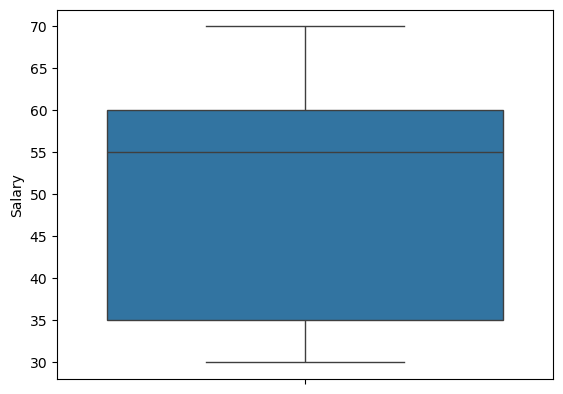

In [192]:
sns.boxplot(data=employee["Salary"]) #This boxplot shows that the mean of the salaries is in 55 and the first 25% of the employees makes 35 of less and the 75% of the employees make 60 or less.
plt.show()

In [193]:
print(employee["Salary"].quantile(0.25))

35.0


In [194]:
print(employee["Salary"].quantile(0.75))

60.0


#### Is the mean salary per gender different?

In [195]:
print(employee.groupby("Gender")["Salary"].mean().round(2)) 
#The mean salary for the women is 47.5 and the mean salary for the men is 50, meaning the women earn less than men in average. 

Gender
F    47.5
M    50.0
Name: Salary, dtype: float64


#### Find the minimum, mean and the maximum of all numeric columns for each Department.

##### Hint: Use functions from Data Manipulation lesson

In [196]:
print(employee.groupby("Department")[["Years", "Salary"]].agg(["min", "max", "mean"]).round(2))

           Years           Salary           
             min max  mean    min max   mean
Department                                  
HR             2   8  4.67     30  70  45.00
IT             1   8  4.50     30  70  48.75
Sales          2   3  2.50     55  55  55.00


### Bonus Question

#### For each department, compute the difference between the maximal salary and the minimal salary.

##### * Hint: try using `agg` or `apply` and `lambda`*

In [197]:
emp_sal = employee.groupby("Department")["Salary"].agg(["max", "min"])
emp_sal["Range"] = emp_sal["max"] - emp_sal["min"] 
print(emp_sal)

            max  min  Range
Department                 
HR           70   30     40
IT           70   30     40
Sales        55   55      0


# Challenge 3

#### Open the Orders.csv dataset. Name your dataset orders

In [198]:
orders = pd.read_csv("Orders.csv")

#### Explore your dataset by looking at the data types and the summary statistics. Comment your results

In [199]:
print(orders.sample(3))
print()
print(orders.info())
print()
print(orders.describe().round(2))

        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
368429      499187     578633     23583  2011     11    4    16   
216937      307054     563900    85099C  2011      8    7    11   
217129      307246     563909     23172  2011      8    7    12   

                           Description  Quantity          InvoiceDate  \
368429        lunch bag paisley park          10  2011-11-24 16:31:00   
216937  jumbo  bag baroque black white       200  2011-08-21 11:05:00   
217129          regency tea plate pink         3  2011-08-21 12:36:00   

        UnitPrice  CustomerID          Country  amount_spent  
368429       1.65       16616   United Kingdom         16.50  
216937       1.79       14566  Channel Islands        358.00  
217129       1.65       15701   United Kingdom          4.95  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397924 entries, 0 to 397923
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        -----------

In [200]:
# This data set has 14 columns with information about sales of different products, the data types we can find in the data set are: int64, object and float64
# with the describe() method we can see the summery statictics of the numeric columns of the df

####  What is the average Purchase Price?

In [ ]:
# the avergae purchase price is: 3.12 

#### What were the highest and lowest purchase prices? 

In [ ]:
# The highest purchase price is: 8142.75 

In [ ]:
# The lowest purchase prices is: 0.00 

#### Select all the customers we have in Spain

In [206]:
spn_cust = orders[orders["Country"] == "Spain"].reset_index()
print(spn_cust)

       index  Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
0       4250        6421     536944     22383  2010     12    5    12   
1       4251        6422     536944     22384  2010     12    5    12   
2       4252        6423     536944     20727  2010     12    5    12   
3       4253        6424     536944     20725  2010     12    5    12   
4       4254        6425     536944     20728  2010     12    5    12   
...      ...         ...        ...       ...   ...    ...  ...   ...   
2480  394733      535271     581193     23291  2011     12    3    17   
2481  394734      535272     581193    85232D  2011     12    3    17   
2482  394735      535273     581193     22721  2011     12    3    17   
2483  394736      535274     581193     23241  2011     12    3    17   
2484  394737      535275     581193     23247  2011     12    3    17   

                        Description  Quantity          InvoiceDate  UnitPrice  \
0           lunch bag suki  design        

#### How many customers do we have in Spain?
##### Hint : Use value_counts()

In [202]:
print(f"Number of customers in Spain is: {spn_cust["CustomerID"].nunique()}")

Number of customers in Spain is: 30


#### Select all the customers who have bought more than 50 items ?

In [207]:
more_50 = orders[orders["Quantity"] > 50]
print(more_50)

        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
46              46     536371     22086  2010     12    3     9   
83              83     536376     21733  2010     12    3     9   
96              96     536378     21212  2010     12    3     9   
102            102     536378    85071B  2010     12    3     9   
174            176     536386    85099C  2010     12    3     9   
...            ...        ...       ...   ...    ...  ...   ...   
397720      541702     581566     23404  2011     12    5    11   
397721      541703     581567     21417  2011     12    5    11   
397729      541711     581567     21326  2011     12    5    11   
397761      541746     581571     23167  2011     12    5    12   
397882      541867     581584     20832  2011     12    5    12   

                               Description  Quantity          InvoiceDate  \
46         paper chain kit 50's christmas         80  2010-12-01 09:00:00   
83        red hanging heart t-light holde

#### Select orders from Spain that are above 50 items

In [208]:
sp_50 = spn_cust[spn_cust["Quantity"] > 50]
print(sp_50)

       index  Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
0       4250        6421     536944     22383  2010     12    5    12   
1       4251        6422     536944     22384  2010     12    5    12   
2       4252        6423     536944     20727  2010     12    5    12   
3       4253        6424     536944     20725  2010     12    5    12   
4       4254        6425     536944     20728  2010     12    5    12   
266    32454       52416     540785    84997B  2011      1    2    11   
267    32455       52417     540785    84997D  2011      1    2    11   
268    32456       52418     540785    84997C  2011      1    2    11   
269    32457       52419     540785    84997A  2011      1    2    11   
749    91155      136767     547972     22383  2011      3    1    16   
750    91156      136768     547972     22384  2011      3    1    16   
753    91159      136771     547972     20728  2011      3    1    16   
1143  174442      248797     558871     22384  2011

#### Select all free orders

In [209]:
free = orders[orders["amount_spent"] == 0]
print(free)

        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
6914          9302     537197     22841  2010     12    7    14   
22539        33576     539263     22580  2010     12    4    14   
25379        40089     539722     22423  2010     12    2    13   
29080        47068     540372     22090  2011      1    4    16   
29082        47070     540372     22553  2011      1    4    16   
34494        56674     541109     22168  2011      1    4    15   
53788        86789     543599    84535B  2011      2    4    13   
85671       130188     547417     22062  2011      3    3    10   
92875       139453     548318     22055  2011      3    3    12   
97430       145208     548871     22162  2011      4    1    14   
107192      157042     550188     22636  2011      4    4    18   
128641      187613     553000     47566  2011      5    4    15   
137127      198383     554037     22619  2011      5    5    14   
194648      279324     561284     22167  2011      7    2    1

#### Select all orders that are 'lunch bag'
#### Hint: Use string functions

In [210]:
lunch_bag_orders = orders[orders["Description"].str.contains("lunch bag", case=False, na=False)]
print(lunch_bag_orders)

        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
93              93     536378     20725  2010     12    3     9   
172            174     536385     22662  2010     12    3     9   
354            363     536401     22662  2010     12    3    11   
359            368     536401     20725  2010     12    3    11   
360            369     536401     22382  2010     12    3    11   
...            ...        ...       ...   ...    ...  ...   ...   
397465      540436     581486     23207  2011     12    5     9   
397713      541695     581538     20727  2011     12    5    11   
397714      541696     581538     20725  2011     12    5    11   
397877      541862     581581     23681  2011     12    5    12   
397880      541865     581583     20725  2011     12    5    12   

                        Description  Quantity          InvoiceDate  UnitPrice  \
93          lunch bag red retrospot        10  2010-12-01 09:37:00       1.65   
172     lunch bag dolly girl desi

#### Select all orders that are made in 2011 and are 'lunch bag'  

In [211]:
lb_orders_11 = lunch_bag_orders[(lunch_bag_orders["year"] == 2011)]
print(lb_orders_11)

        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
26340        42678     540015     20725  2011      1    2    11   
26341        42679     540015     20726  2011      1    2    11   
26512        42851     540023     22382  2011      1    2    12   
26513        42852     540023     20726  2011      1    2    12   
26860        43616     540098     22384  2011      1    2    15   
...            ...        ...       ...   ...    ...  ...   ...   
397465      540436     581486     23207  2011     12    5     9   
397713      541695     581538     20727  2011     12    5    11   
397714      541696     581538     20725  2011     12    5    11   
397877      541862     581581     23681  2011     12    5    12   
397880      541865     581583     20725  2011     12    5    12   

                        Description  Quantity          InvoiceDate  UnitPrice  \
26340       lunch bag red retrospot        10  2011-01-04 11:40:00       1.65   
26341            lunch bag woodla

#### Show the frequency distribution of the amount spent in Spain.

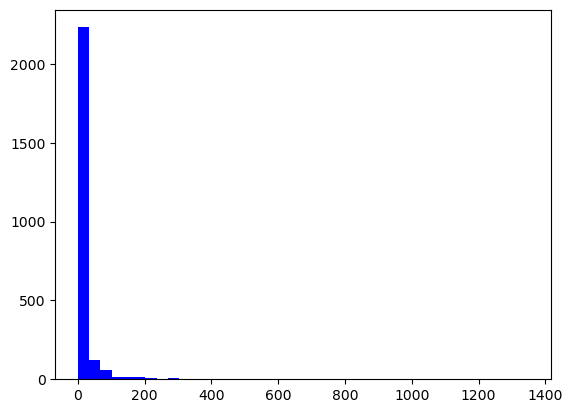

In [149]:
plt.hist(spn_cust["amount_spent"], bins = 40, color="blue")
plt.show()

#### Select all orders made in the month of August

In [212]:
aug_ord = orders[orders["month"] == 8]
print(aug_ord)

        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
199475      285421     561904     22075  2011      8    1     8   
199476      285422     561904    85049E  2011      8    1     8   
199477      285423     561905     21385  2011      8    1     9   
199478      285424     561905    84970L  2011      8    1     9   
199479      285425     561905    84970S  2011      8    1     9   
...            ...        ...       ...   ...    ...  ...   ...   
226483      320688     565067     22644  2011      8    3    17   
226484      320689     565067     22645  2011      8    3    17   
226485      320690     565067     22637  2011      8    3    17   
226486      320691     565067     22646  2011      8    3    17   
226487      320692     565067     22741  2011      8    3    17   

                                Description  Quantity          InvoiceDate  \
199475         6 ribbons elegant christmas         96  2011-08-01 08:30:00   
199476            scandinavian reds rib

#### Select how many orders are made by countries in the month of August
##### Hint: Use value_counts()

In [153]:
countries_aug = aug_ord.groupby("Country")["Country"].value_counts()
print(countries_aug)

Country
Australia            107
Austria               88
Belgium              194
Canada                 5
Channel Islands      140
Denmark               16
EIRE                 593
Finland               61
France               569
Germany              795
Iceland               22
Israel               171
Italy                 95
Malta                 55
Netherlands          280
Norway                77
Poland                17
Portugal              41
Spain                252
Sweden                40
Switzerland          267
United Kingdom     23105
Unspecified           23
Name: count, dtype: int64


#### What's the  average amount of money spent by country

In [163]:
countr_av = orders.groupby("Country")["amount_spent"].mean().round(2)
print(countr_av)

Country
Australia               116.90
Austria                  25.62
Bahrain                  32.26
Belgium                  20.28
Brazil                   35.74
Canada                   24.28
Channel Islands          27.34
Cyprus                   22.13
Czech Republic           33.07
Denmark                  49.88
EIRE                     36.69
European Community       21.67
Finland                  32.91
France                   25.06
Germany                  25.31
Greece                   32.83
Iceland                  23.68
Israel                   29.12
Italy                    23.06
Japan                   116.56
Lebanon                  37.64
Lithuania                47.46
Malta                    24.34
Netherlands             120.80
Norway                   33.74
Poland                   22.23
Portugal                 22.87
RSA                      17.28
Saudi Arabia             16.21
Singapore                95.85
Spain                    24.78
Sweden                   85.10


#### What's the most expensive item?

In [213]:
max_p = orders["UnitPrice"].max()
exp_item = orders[orders["UnitPrice"] == max_p]["Description"].values[0]
print(f"The most expensive item is: {exp_item}")

The most expensive item is: postage


#### What was the average amount spent per year ?

In [214]:
print("The average amount spent per year:")
print(orders.groupby("year")["amount_spent"].mean())

The average amount spent per year:
year
2010    21.892733
2011    22.430074
Name: amount_spent, dtype: float64
